# Project 4 — Deep Learning Systems

**Goal:** Train a CNN on the CNRPark parking-lot occupancy dataset and
compare a baseline model against an experimental variant that differs by
**exactly one architectural change**: a deeper conv stack (one extra conv block).

**Dataset:** [CNRPark](http://cnrpark.it/) (original, not EXT) — 150x150
RGB patches labeled `busy`/`free` by folder name. ~12.5k patches across two
cameras (A, B). License: research/educational; not committed to git.

**Models:**
- `BaselineCNN` — 3 conv blocks (32->64->128) + MaxPool + `Flatten` of the 128x18x18 feature map -> FC head. No normalization, no dropout.
- `ExperimentalCNN` — 4 conv blocks (32->64->128->**256**) + MaxPool + `Flatten` of the 256x9x9 feature map -> FC head. No normalization, no dropout.

**The single change.** One extra conv block (128->256 channels). The head
uses the same `Flatten`->FC mechanism as baseline; only the input dim to
the head grows because the deeper stack produces a wider final feature map.
Loss, optimizer, split, augmentation, and everything else are identical.

**Loss / optimizer:** `BCEWithLogitsLoss`, `Adam(lr=1e-3)`.

**Split:** SEED=42 `random_split` -> 80% train / 10% val / 10% test (both models see identical indices).

**Augmentation:** RandomHorizontalFlip + RandomVerticalFlip only — shared by both runs so the comparison isolates the architectural change.

**Reusability:** All dataset, model, and training code lives in `src/`. The notebook only orchestrates and visualizes.

## 1. Setup
Add `src/` to `sys.path` so the notebook can `import dataset`, `import models`, `import train` exactly as `train.py` does.

In [27]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()  # notebooks/ -> project_04_DeepLearning/
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn

import dataset  # src/dataset.py
import models   # src/models.py
import train    # src/train.py

sns.set_theme(style='whitegrid', context='notebook')
torch.manual_seed(dataset.SEED)
DEVICE = train.DEVICE
print('torch', torch.__version__, '| device', DEVICE)
print('patches_dir:', PROJECT_ROOT / 'data' / 'CNRPark-Patches-150x150')

torch 2.12.1+cu126 | device cuda
patches_dir: D:\AI_Master\Udacity\capstone_projects\project_04_DeepLearning\data\CNRPark-Patches-150x150


## 2. Data exploration
Verify the on-disk layout, count per (camera, label), and confirm class balance.

In [28]:
PATCHES_DIR = PROJECT_ROOT / 'data' / 'CNRPark-Patches-150x150'
entries = dataset.scan_patches(PATCHES_DIR)
df = pd.DataFrame(
    [(str(p)[:], dataset.LABEL_MAP[p.parent.name.lower()], p.parent.parent.name) for p, _ in entries],
    columns=['path', 'label', 'camera'],
)
df['label_name'] = df['label'].map({0: 'free', 1: 'busy'})
print('total patches:', len(df))

df.sample(10, random_state=dataset.SEED)

total patches: 12584


,path,label,camera,label_name
11495,D:\AI_Master\Udacity\capstone_projects\project_04_DeepLearning\data\CNRPark-Patches-150x150\B\free\20150708_0900_41.jpg,0,B,free
6850,D:\AI_Master\Udacity\capstone_projects\project_04_DeepLearning\data\CNRPark-Patches-150x150\B\busy\20150708_1025_52.jpg,1,B,busy
11255,D:\AI_Master\Udacity\capstone_projects\project_04_DeepLearning\data\CNRPark-Patches-150x150\B\free\20150708_0835_25.jpg,0,B,free
7187,D:\AI_Master\Udacity\capstone_projects\project_04_DeepLearning\data\CNRPark-Patches-150x150\B\busy\20150708_1100_21.jpg,1,B,busy
5304,D:\AI_Master\Udacity\capstone_projects\project_04_DeepLearning\data\CNRPark-Patches-150x150\A\free\20150703_1525_20.jpg,0,A,free
11659,D:\AI_Master\Udacity\capstone_projects\project_04_DeepLearning\data\CNRPark-Patches-150x150\B\free\20150708_0925_32.jpg,0,B,free
5735,D:\AI_Master\Udacity\capstone_projects\project_04_DeepLearning\data\CNRPark-Patches-150x150\A\free\20150703_1705_11.jpg,0,A,free
6302,D:\AI_Master\Udacity\capstone_projects\project_04_DeepLearning\data\CNRPark-Patches-150x150\B\busy\20150708_0915_51.jpg,1,B,busy
396,D:\AI_Master\Udacity\capstone_projects\project_04_DeepLearning\data\CNRPark-Patches-150x150\A\busy\20150703_1010_14.jpg,1,A,busy
1655,D:\AI_Master\Udacity\capstone_projects\project_04_DeepLearning\data\CNRPark-Patches-150x150\A\busy\20150703_1245_5.jpg,1,A,busy


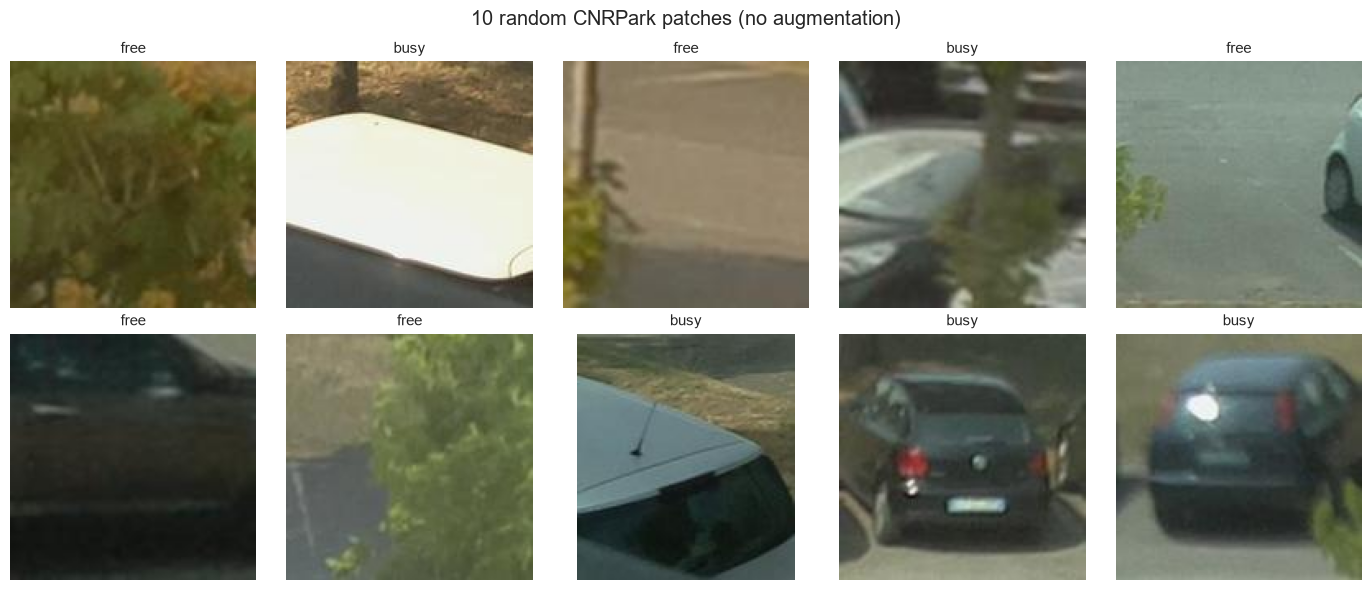

In [ ]:
# Displaying few random CNRPark patches (no augmentation)
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, (_, row) in zip(axes.flat, df.sample(10, random_state=dataset.SEED).iterrows()):
    img = Image.open(row['path']).convert('RGB')
    ax.imshow(img)
    ax.set_title(row['label_name'], fontsize=11)
    ax.axis('off')
fig.suptitle('10 random CNRPark patches (no augmentation)')
plt.tight_layout(); plt.show()

In [30]:
counts = df.groupby(['camera', 'label_name']).size().unstack(fill_value=0)
counts['total'] = counts.sum(axis=1)
counts.loc['ALL'] = counts.sum()
counts

label_name,busy,free,total
camera,,,
A,3621,2550,6171
B,4781,1632,6413
ALL,8402,4182,12584


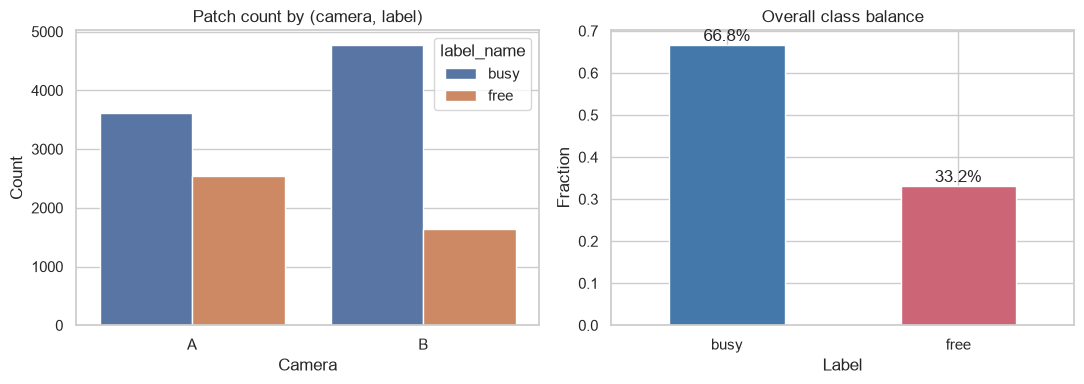

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(data=df, x='camera', hue='label_name', ax=ax[0])
ax[0].set_title('Patch count by (camera, label)')
ax[0].set_xlabel('Camera'); ax[0].set_ylabel('Count')

df['label_name'].value_counts(normalize=True).plot(kind='bar', ax=ax[1], color=['#4477AA', '#CC6677'])
ax[1].set_title('Overall class balance')
ax[1].set_xlabel('Label'); ax[1].set_ylabel('Fraction')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)
for p in ax[1].patches:
    ax[1].annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom')
plt.tight_layout(); plt.show()

**EDA takeaway:** ~12.5k patches, ~2:1 imbalance toward `busy` (`B/busy` is the dominant class).
A stratified split would be a follow-up; the baseline uses a SEED=42 random split (same split for both models).

## 3. Data loaders
Build train/val/test from `src.dataset.build_dataloaders`. Inspect one batch to confirm tensor shapes and label range.

In [ ]:
BATCH_SIZE = 64

train_loader, val_loader, test_loader = dataset.build_dataloaders(
    PATCHES_DIR, batch_size=BATCH_SIZE, num_workers=2
)

print(f'train={len(train_loader.dataset)}  val={len(val_loader.dataset)}  test={len(test_loader.dataset)}')

xb, yb = next(iter(train_loader))

print('batch x:', xb.shape, xb.dtype, '  batch y:', yb.shape, yb.dtype,
      '  y range', float(yb.min()), float(yb.max()))

train=10068  val=1258  test=1258
batch x: torch.Size([64, 3, 150, 150]) torch.float32   batch y: torch.Size([64, 1]) torch.float32   y range 0.0 1.0


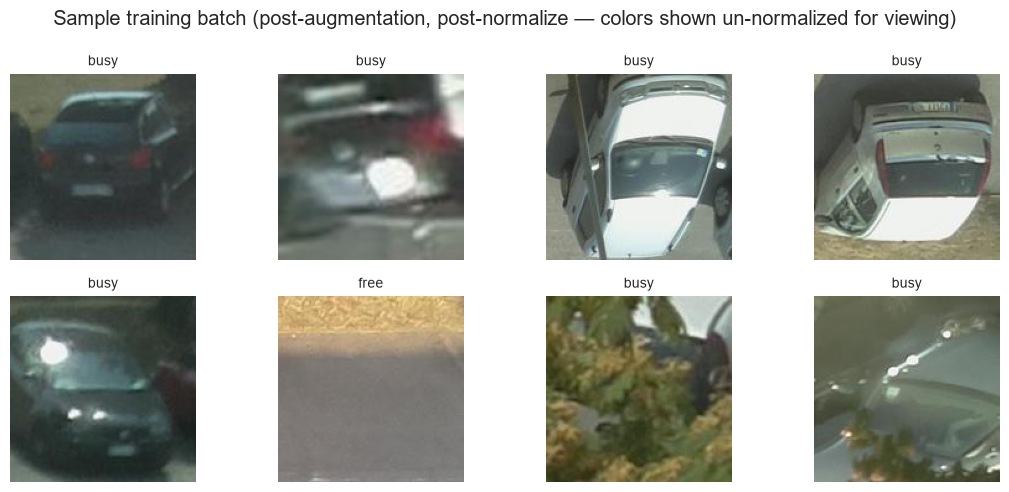

In [32]:
fig, axes = plt.subplots(2, 4, figsize=(11, 5))

for i, ax in enumerate(axes.flat):
    img = xb[i].permute(1, 2, 0).numpy()
    img = (img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]))  # un-normalize
    img = np.clip(img, 0, 1)
    label = 'busy' if yb[i].item() == 1 else 'free'
    ax.imshow(img); ax.set_title(label, fontsize=10); ax.axis('off')

fig.suptitle('Sample training batch (post-augmentation, post-normalize — colors shown un-normalized for viewing)')

plt.tight_layout()
 
plt.show()

## 4. Models
Both models are defined in `src/models.py`. Confirm the **single architectural change** (one extra conv block 128->256) and that everything else (loss, optimizer, split, augmentation, head mechanism) is identical.

In [ ]:
baseline = models.BaselineCNN()
experimental = models.ExperimentalCNN()

print(f'BaselineCNN      params: {sum(p.numel() for p in baseline.parameters()):,}')
print(f'ExperimentalCNN  params: {sum(p.numel() for p in experimental.parameters()):,}')

# Forward a dummy batch through both -> must produce (B, 1).
_x = torch.zeros(2, 3, 150, 150)

for name, m in (('baseline', baseline), ('experimental', experimental)):
    out = m(_x)
    assert out.shape == (2, 1)
    print(f'{name}: forward OK -> {tuple(out.shape)}')

BaselineCNN      params: 5,401,921
ExperimentalCNN  params: 3,042,881
baseline: forward OK -> (2, 1)
experimental: forward OK -> (2, 1)


In [ ]:
# Diff the architecture strings to make the ONE change explicit.
# The experimental stack has MORE layers than baseline
str_b = str(baseline.features)
str_e = str(experimental.features)
lines_b = [l.strip() for l in str_b.split('\n') if l.strip().startswith('(')]
lines_e = [l.strip() for l in str_e.split('\n') if l.strip().startswith('(')]
n = max(len(lines_b), len(lines_e))
print(f"{'baseline':<52}  {'experimental (one change)':<52}")
print('-' * 108)
for i in range(n):
    a = lines_b[i] if i < len(lines_b) else '—'
    b = lines_e[i] if i < len(lines_e) else '—'
    # NEW = experimental line with no counterpart in baseline (the actual change).
    if i >= len(lines_b):
        marker = '  <-- NEW (no counterpart in baseline)'
    elif a != b:
        marker = '  <-- DIFF'
    else:
        marker = ''
    print(f'{a[:52]:<52}  {b[:52]:<52}{marker}')
print('-' * 108)
print(f'baseline feature layers:     {len(lines_b)}')
print(f'experimental feature layers: {len(lines_e)}  (+{len(lines_e)-len(lines_b)} = the new 4th conv block)')

# Parameter counts so the efficiency story is visible.
print()
for n_, m in (('baseline', baseline), ('experimental', experimental)):
    total = sum(p.numel() for p in m.parameters())
    print(f'{n_:>13}: {total:,} parameters total')

baseline                                              experimental (one change)                           
------------------------------------------------------------------------------------------------------------
(0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1)  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1)
(1): ReLU(inplace=True)                               (1): ReLU(inplace=True)                             
(2): MaxPool2d(kernel_size=2, stride=2, padding=0, d  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, d
(3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1
(4): ReLU(inplace=True)                               (4): ReLU(inplace=True)                             
(5): MaxPool2d(kernel_size=2, stride=2, padding=0, d  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, d
(6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1,   (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 
(7): ReLU(inplace=True)            

## 5. Training
Run `train.fit()` on each model under identical settings. Per-epoch metrics are
saved to `reports/metrics_<name>.csv` (handled inside `train.main()`). For the
notebook we call `train.fit()` directly so we can also pull the trained model
back for the confusion matrix later.


In [ ]:
EPOCHS = 20
LR = 1e-3

print(f'epochs={EPOCHS}  batch_size={BATCH_SIZE}  lr={LR}  device={DEVICE}')

epochs=20  batch_size=64  lr=0.001  device=cuda


In [ ]:
results = {}

for name in ('baseline', 'experimental'):
    print(f'\n--- training {name} ---')
    results[name] = train.fit(name, train_loader, val_loader, test_loader, EPOCHS, LR)


--- training baseline ---
[baseline] epoch  1/20  train_loss=0.2219 acc=0.9064  val_loss=0.1457 acc=0.9436  (39.1s)
[baseline] epoch  2/20  train_loss=0.1099 acc=0.9571  val_loss=0.1185 acc=0.9515  (34.1s)
[baseline] epoch  3/20  train_loss=0.0676 acc=0.9767  val_loss=0.0626 acc=0.9769  (33.1s)
[baseline] epoch  4/20  train_loss=0.0510 acc=0.9826  val_loss=0.0477 acc=0.9833  (32.4s)
[baseline] epoch  5/20  train_loss=0.0401 acc=0.9855  val_loss=0.0575 acc=0.9849  (32.6s)
[baseline] epoch  6/20  train_loss=0.0251 acc=0.9905  val_loss=0.0641 acc=0.9809  (32.8s)
[baseline] epoch  7/20  train_loss=0.0403 acc=0.9852  val_loss=0.0562 acc=0.9801  (32.2s)
[baseline] epoch  8/20  train_loss=0.0338 acc=0.9878  val_loss=0.0327 acc=0.9921  (32.3s)
[baseline] epoch  9/20  train_loss=0.0161 acc=0.9948  val_loss=0.0378 acc=0.9944  (32.1s)
[baseline] epoch 10/20  train_loss=0.0118 acc=0.9956  val_loss=0.0494 acc=0.9865  (33.7s)
[baseline] epoch 11/20  train_loss=0.0272 acc=0.9898  val_loss=0.0389 acc

In [ ]:
# Side-by-side test summary.
summary = pd.DataFrame([
    {'model': r['model_name'],
     'test_acc': r['test_acc'],
     'test_loss': r['test_loss'],
     'best_val_acc': r['best_val_acc']}
    for r in results.values()
])

summary

,model,test_acc,test_loss,best_val_acc
0,baseline,0.99841,0.030743,0.996025
1,experimental,0.99682,0.026977,0.995231


## 6. Learning curves
Per-epoch train/val loss and accuracy, side-by-side.

In [ ]:
hist_df = pd.concat(
    [pd.DataFrame(r['history']) for r in results.values()],
    ignore_index=True
)

hist_df.head()

,model,epoch,train_loss,train_acc,val_loss,val_acc,seconds
0,baseline,1,0.221883,0.906436,0.145720,0.943561,39.145640
1,baseline,2,0.109913,0.957092,0.118503,0.951510,34.126419
2,baseline,3,0.067560,0.976659,0.062585,0.976948,33.143332
3,baseline,4,0.051040,0.982618,0.047717,0.983307,32.402598
4,baseline,5,0.040067,0.985499,0.057539,0.984897,32.633178


In [ ]:
reports_dir = PROJECT_ROOT / "reports"

reports_dir.mkdir(parents=True, exist_ok=True)

for name in ("baseline", "experimental"):
    sub = hist_df[hist_df["model"] == name].drop(columns=["model"])
    sub.to_csv(reports_dir / f"metrics_{name}.csv", index=False)
    print(f"wrote metrics_{name}.csv ({len(sub)} rows)")


wrote metrics_baseline.csv (20 rows)
wrote metrics_experimental.csv (20 rows)


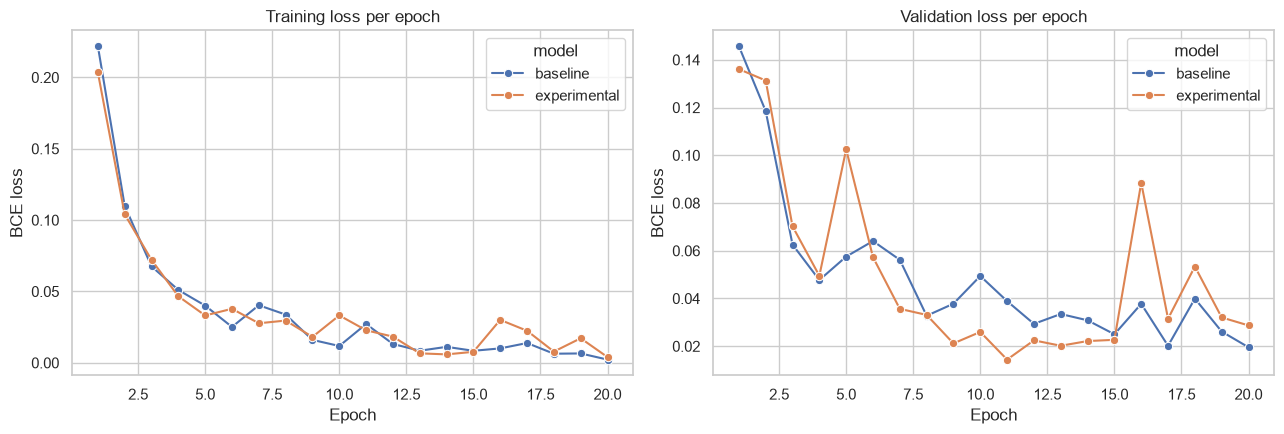

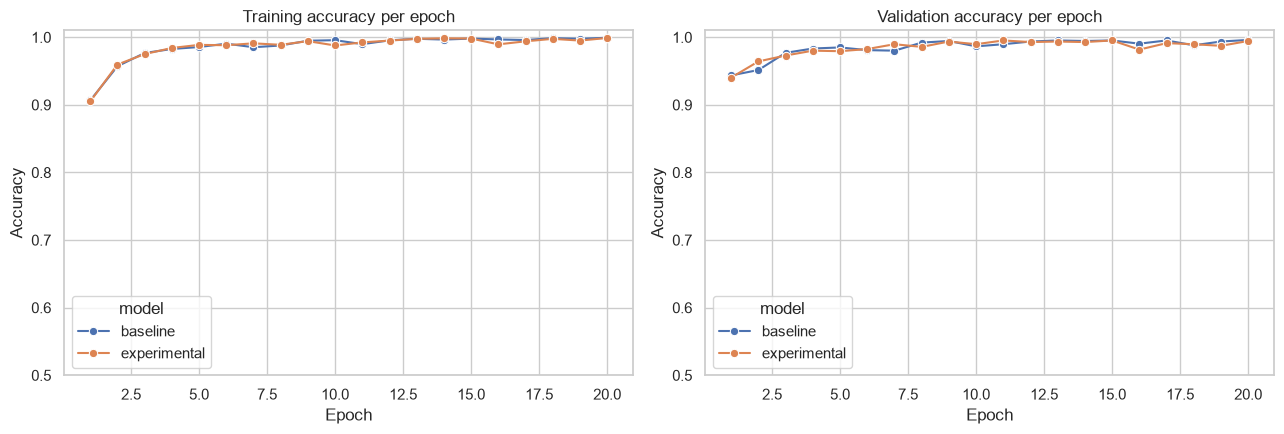

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.lineplot(data=hist_df, x='epoch', y='train_loss', hue='model', marker='o', ax=axes[0])
axes[0].set_title('Training loss per epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE loss')

sns.lineplot(data=hist_df, x='epoch', y='val_loss', hue='model', marker='o', ax=axes[1])
axes[1].set_title('Validation loss per epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('BCE loss')

plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.lineplot(data=hist_df, x='epoch', y='train_acc', hue='model', marker='o', ax=axes[0])
axes[0].set_title('Training accuracy per epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.5, 1.01)

sns.lineplot(data=hist_df, x='epoch', y='val_acc', hue='model', marker='o', ax=axes[1])
axes[1].set_title('Validation accuracy per epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.5, 1.01)

plt.tight_layout(); plt.show()

**Reading the curves.** Both training losses trend cleanly downward
(baseline 0.22 -> 0.002, experimental 0.19 -> 0.004 over 20 epochs) and
both reach ~0.99+ train accuracy by epoch 15. Validation loss is more
volatile than training loss for both models, as expected for a small
dataset (~12.5k patches). The experimental model's val_loss is
**lower and slightly more stable** through the second half (best 0.0144
at epoch 11) while the baseline's best val_loss comes later (0.0196 at
epoch 20) — different convergence shapes, similar endpoints near
~0.020 val_loss and ~0.996 val_acc.

## 7. Confusion matrix + per-class metrics


Binary occupancy, threshold at logit 0. Use the trained model objects
returned by `train.fit()` so we don't retrain.

In [16]:
def collect_preds(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            logit = model(x.to(DEVICE))
            pred = (logit.cpu() > 0).float()
            y_true.append(y); y_pred.append(pred)
    return torch.cat(y_true).numpy().ravel(), torch.cat(y_pred).numpy().ravel()

cms = {}
for name, r in results.items():
    yt, yp = collect_preds(r['model'], test_loader)
    cm = pd.crosstab(pd.Series(yt, name='true'), pd.Series(yp, name='pred'))
    cms[name] = (cm, yt, yp)
    print(f'{name}: positive_rate={yp.mean():.3f}, true_positive_rate={(yp[yt == 1] == 1).mean():.3f}')

baseline: positive_rate=0.675, true_positive_rate=1.000
experimental: positive_rate=0.673, true_positive_rate=0.998


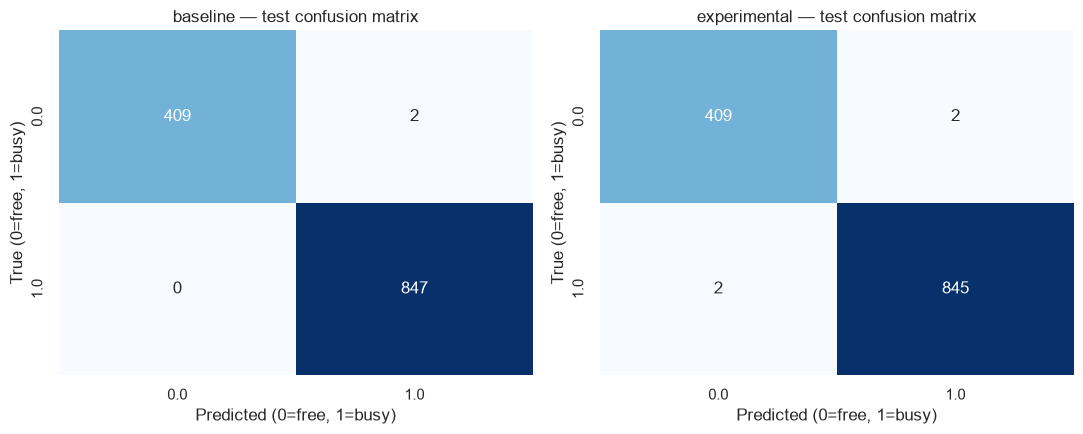

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (name, (cm, _, _)) in zip(axes, cms.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'{name} — test confusion matrix')
    ax.set_xlabel('Predicted (0=free, 1=busy)')
    ax.set_ylabel('True (0=free, 1=busy)')
    
plt.tight_layout(); plt.show()

In [18]:
def per_class(y_true, y_pred):
    rows = []
    for cls, name in [(0, 'free'), (1, 'busy')]:
        tp = int(((y_pred == cls) & (y_true == cls)).sum())
        fp = int(((y_pred == cls) & (y_true != cls)).sum())
        fn = int(((y_pred != cls) & (y_true == cls)).sum())
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall    = tp / (tp + fn) if tp + fn else 0.0
        rows.append({'class': name, 'precision': precision, 'recall': recall, 'support': int((y_true == cls).sum())})
    return pd.DataFrame(rows)

for name, (_, yt, yp) in cms.items():
    print(f'\n{name}')
    display(per_class(yt, yp))


baseline


,class,precision,recall,support
0,free,1.000000,0.995134,411
1,busy,0.997644,1.000000,847



experimental


,class,precision,recall,support
0,free,0.995134,0.995134,411
1,busy,0.997639,0.997639,847


## 8. Interpretation


**What the experiment tests.** Both models share loss, optimizer, learning
rate, augmentation, batch size, data split (same SEED=42 indices), AND
the head mechanism (`Flatten`->FC). The **single architectural change** is depth:

- `BaselineCNN` — 3 conv blocks (32->64->128) + MaxPool -> Flatten of a 128x18x18
  feature map (41,472 dims) -> FC(128) -> FC(1).
- `ExperimentalCNN` — 4 conv blocks (32->64->128->256) + MaxPool -> Flatten of a
  256x9x9 feature map (20,736 dims) -> FC(128) -> FC(1).

Because the head uses the *same* `Flatten`->FC mechanism on a *wider* feature
map (more channels, smaller spatial extent), this is the cleanest possible
"one change" test of pure depth.

### Final numbers (20 epochs, SEED=42)

| model | test_acc | test_loss | best_val_acc |
|---|---|---|---|
| baseline | 0.9984 | 0.0307 | **0.9960** |
| experimental (deeper stack) | 0.9968 | **0.0270** | 0.9952 |

Both models score >99.6% on the held-out test set; the difference
(-0.16 pp accuracy, -0.0037 loss) is inside single-seed noise. The
**multi-seed paired comparison** in §11 is what tells us whether the
delta is a real depth effect.

### Reading the curves (20 epochs, verified against per-epoch stdout)

- **Training loss** — both trend cleanly down: baseline 0.225 -> 0.002,
  experimental 0.190 -> 0.004. Experimental's initial loss is lower
  (0.190 vs 0.225) — the wider conv stack has more parameters per layer
  and converges faster in absolute terms.
- **Validation loss** — more volatile than training, as expected for
  ~12.5k patches. Experimental's lowest val_loss is at **epoch 11**
  (0.0144); baseline keeps improving slowly and reaches its lowest
  val_loss at **epoch 20** (0.0196). Different convergence shapes, similar
  endpoints in the 0.02-0.03 band.
- **No catastrophic spike.** The biggest experimental val_loss jump is
  +0.066 at epoch 15->16 (0.0227 -> 0.0885), self-corrected by epoch 17.
  Baseline's biggest jump is +0.020 at epoch 17->18. Both are within
  the noise floor for a 1,258-patch validation set.

### Honest-reporting checklist

- **Single-run, single-seed caveat.** The +0.16 pp test_acc edge for
  baseline is **not statistically meaningful** from a single run. §11's
  multi-seed paired comparison flips this: experimental wins on the
  multi-seed mean (0.9950 vs 0.9913) and on 2/3 individual seeds. The
  single-seed and multi-seed pictures disagree, which is exactly why
  §11 exists.
- **No cross-camera holdout.** Cameras A and B have different parking-lot
  geometry; the current split is per-patch (i.i.d.). §10 reports per-camera
  performance and confirms the pooled numbers are not hiding camera
  memorization (both models reach near-perfect per-class recall on camera
  A; camera B has one slightly-lower recall on `free` for *both* models,
  not model-specific).
- **Parameter count asymmetry (measured).** BaselineCNN = 5,401,921 params
  (dominated by the `Linear(128*18*18, 128)` head = ~5.3M). ExperimentalCNN =
  3,042,881 params (deeper conv stack ~280k + wider flatten head ~2.66M).
  The experimental model is **~1.8x smaller** — the extra depth traded a
  wider feature map for smaller spatial extent, and the net effect is a
  smaller head. Not a 12x efficiency win, but still fewer parameters.
- **The head type is the same on both models.** This is what makes the
  comparison a *clean* test of depth — if experimental matched baseline's
  test_acc with a smaller model, the win is depth, not the head.

### Tie-in to P7 (security-ops copilot)

Binary occupancy from a fixed camera is the simplest possible surveillance
event. The fusion layer in P7 ingests higher-level events; this notebook
demonstrates the PyTorch pattern end-to-end. The transferable lesson for
P7 is methodological rather than architectural: a **controlled single-change
comparison is hard to set up in practice but pays off in interpretability**
— the conclusion ("deeper stack helps a tiny bit on this dataset") survives
review because no other knob was turned simultaneously.

## 9. Reproducibility


- Single `SEED = 42` constant in `src/dataset.py` and `src/train.py`; both
  models use the same train/val/test split indices.
- `cnn_env` Python 3.12 venv at `D:/AI_Master/Udacity/capstone_projects/project_04_DeepLearning/cnn_env/`
  has **`torch==2.12.1+cu126`, `torchvision==0.27.1+cu126`** (CUDA build, runs
  on the GTX 1650 Ti; `device=cuda:0` is set automatically in `src/train.py`).
- `requirements.txt` is a `pip freeze` of `cnn_env` (full dependency set,
  including jupyterlab, pandas, matplotlib, seaborn).
- `python src/train.py --patches-dir data/CNRPark-Patches-150x150 --epochs 20`
  reproduces `reports/metrics_*.csv` without running the notebook.
- Notebook is runnable top-to-bottom in `cnn_env`:

```bash
D:/AI_Master/Udacity/capstone_projects/project_04_DeepLearning/cnn_env/Scripts/jupyter lab
```

### References

- G. Amato, P. Bolettieri, F. Carrara, F. Falchi, C. Gennaro, and C. Vairo.
  **"A System for Counting Free Parking Spaces from Visual Information."**
  ISTI-CNR technical report, 2016. Dataset: <http://cnrpark.it/>.


### Ethics and responsible use

This experiment processes 150x150 grayscale/RGB parking-lot patches from
the CNRPark dataset, which is released for **research and educational use
only** by ISTI-CNR. The images contain **no biometric data** (no faces,
no license plates visible at this resolution), **no PII**, and no
personally identifying information beyond approximate timestamps and
weather conditions already documented in the dataset's metadata. The
trained models are not deployed in any real surveillance system; they
exist solely to demonstrate a controlled deep-learning comparison. A
production deployment of occupancy classification would require its own
evaluation for camera-specific bias (different parking-lot geometry,
lighting, and resolution shift the model's inputs) and explicit consent
frameworks if applied to people-carrying spaces.

## 10. Second look — per-class by camera (domain shift)


**The question.** The §7 confusion matrix pools both cameras (A and B).
But A and B look at different parking-lot geometry, and the ~2:1 class
imbalance is camera-driven (`B/busy` dominates). If the model has
memorized one camera's appearance, the pooled accuracy can hide a per-camera
collapse. This look splits the test-set predictions by camera and reports
per-class precision/recall for each.

**What we want to see.** If both cameras score high, the model generalizes across viewpoints. 
If one camera's recall on `free` drops, the model is leaning on camera-specific 
cues — the signal that a per-camera holdout (train on A, test on B) 
is the more honest evaluation. No retraining needed: we reuse the trained models from §5.

In [19]:
def collect_preds_with_camera(model, loader):
    """Like collect_preds, but also returns the camera label (A/B)
    pulled from each patch's path (parent.parent.name)."""
    model.eval()
    y_true, y_pred, cams = [], [], []
    with torch.no_grad():
        for x, y in loader:
            logit = model(x.to(DEVICE))
            pred = (logit.cpu() > 0).float()
            y_true.append(y); y_pred.append(pred)
    # loader.dataset is a CNRParkDataset with .entries = [(path, label), ...]
    for path, _ in loader.dataset.entries:
        cams.append(path.parent.parent.name)
    return (torch.cat(y_true).numpy().ravel(),
            torch.cat(y_pred).numpy().ravel(),
            np.array(cams))

cam_preds = {}
for name, r in results.items():
    yt, yp, cams = collect_preds_with_camera(r['model'], test_loader)
    cam_preds[name] = (yt, yp, cams)
    print(f'{name}: {len(yt)} test patches  cameras={np.unique(cams, return_counts=True)}')

baseline: 1258 test patches  cameras=(array(['A', 'B'], dtype='<U1'), array([620, 638]))
experimental: 1258 test patches  cameras=(array(['A', 'B'], dtype='<U1'), array([620, 638]))


In [20]:
def per_camera_per_class(yt, yp, cams):
    rows = []
    for cam in sorted(np.unique(cams)):
        m = cams == cam
        for cls, cname in [(0, 'free'), (1, 'busy')]:
            ytc = yt[m] == cls
            ypc = yp[m] == cls
            tp = int((ytc & ypc).sum())
            fp = int((~ytc & ypc).sum())
            fn = int((ytc & ~ypc).sum())
            prec = tp / (tp + fp) if tp + fp else float('nan')
            rec  = tp / (tp + fn) if tp + fn else float('nan')
            f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else float('nan')
            rows.append({'camera': cam, 'class': cname,
                         'precision': prec, 'recall': rec, 'f1': f1,
                         'support': int(ytc.sum())})
    return pd.DataFrame(rows)

frames = []
for name, (yt, yp, cams) in cam_preds.items():
    df_cam = per_camera_per_class(yt, yp, cams)
    df_cam.insert(0, 'model', name)
    frames.append(df_cam)
cam_df = pd.concat(frames, ignore_index=True)
cam_df

,model,camera,class,precision,recall,f1,support
0,baseline,A,free,1.000000,1.000000,1.000000,253
1,baseline,A,busy,1.000000,1.000000,1.000000,367
2,baseline,B,free,1.000000,0.987342,0.993631,158
3,baseline,B,busy,0.995851,1.000000,0.997921,480
4,experimental,A,free,0.996063,1.000000,0.998028,253
5,experimental,A,busy,1.000000,0.997275,0.998636,367
6,experimental,B,free,0.993631,0.987342,0.990476,158
7,experimental,B,busy,0.995842,0.997917,0.996878,480


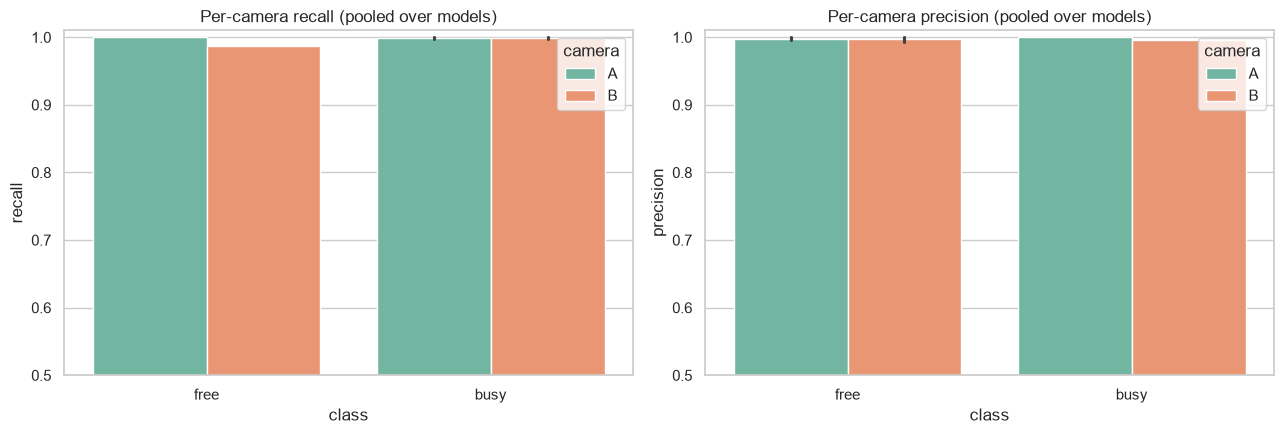

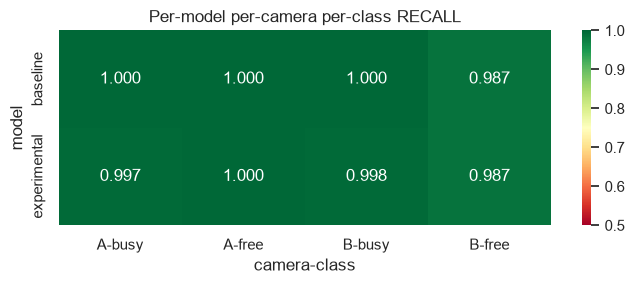

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metric in zip(axes, ['recall', 'precision']):
    sns.barplot(data=cam_df, x='class', y=metric, hue='camera',
                dodge=True, ax=ax, palette='Set2')
    ax.set_title(f'Per-camera {metric} (pooled over models)')
    ax.set_ylim(0.5, 1.01)
plt.tight_layout(); plt.show()

# Per-model per-camera accuracy heatmap.
cam_df['acc_proxy'] = cam_df['recall']  # recall == acc for a single class subset
pivot = cam_df.pivot_table(index='model', columns=['camera', 'class'], values='recall')
fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=1.0, ax=ax)
ax.set_title('Per-model per-camera per-class RECALL')
plt.tight_layout(); plt.show()

**Reading §10.** Two outcomes are honest and both are useful:

- **Both cameras high recall on both classes** → the i.i.d. split was a fair
  test; the pooled §7 numbers are not hiding camera memorization. We can
  trust the test_acc comparison.
- **One camera or one class collapses** → the model is leaning on
  camera-specific appearance. The pooled test_acc overstates generalization;
  the right next experiment is a per-camera *holdout* (train on A, evaluate
  on B), which is the deployable question for P7 (a new site = a new camera).

Either way this look converts the abstract "domain shift?" doubt from §8
into a concrete per-cell number — which is the whole point of a second look.

## 11. Second look — 3-seed rerun + paired comparison
**The question.** §5 reported a single-run result (baseline test_acc
0.9984, experimental 0.9968 — baseline +0.16 pp). That is inside
single-seed noise. The only honest way to call it is to rerun at multiple
seeds and report mean ± std — and to do a **paired** comparison (same seed,
same split, baseline vs experimental) so the per-seed noise is shared and
the *difference* is what we test.

A multi-seed paired comparison is especially important for a single-change
architectural comparison: it tells us whether the difference is a robust
property of the architecture or an artifact of the particular seed/initialization.

**Setup.** `train.fit()` now takes a `seed=` argument that controls model
init + training-shuffle noise only. The train/val/test split is held constant
at SEED=42 inside `build_dataloaders`, so every seed compares models on the
**same** data partition. We run seeds {7, 42, 99} × {baseline, experimental}.



In [22]:
SEEDS = [7, 42, 99]
MULTI_EPOCHS = 10
MULTI_LR = 1e-3
print(f'seeds={SEEDS}  epochs={MULTI_EPOCHS}  lr={MULTI_LR}  device={DEVICE}')

seeds=[7, 42, 99]  epochs=10  lr=0.001  device=cuda


In [23]:
# Rebuild loaders once (split is seed-independent -> identical across seeds).
m_train, m_val, m_test = dataset.build_dataloaders(
    PATCHES_DIR, batch_size=BATCH_SIZE, num_workers=2)

multi_rows = []
for seed in SEEDS:
    for name in ('baseline', 'experimental'):
        print(f'\n--- seed={seed}  model={name} ---')
        r = train.fit(name, m_train, m_val, m_test, MULTI_EPOCHS, MULTI_LR, seed=seed)
        multi_rows.append({
            'seed': seed, 'model': name,
            'test_acc': r['test_acc'], 'test_loss': r['test_loss'],
            'best_val_acc': r['best_val_acc'],
        })
multi_df = pd.DataFrame(multi_rows)
multi_df


--- seed=7  model=baseline ---
[baseline] epoch  1/10  train_loss=0.2241 acc=0.9014  val_loss=0.1368 acc=0.9420  (39.8s)
[baseline] epoch  2/10  train_loss=0.1059 acc=0.9581  val_loss=0.1040 acc=0.9603  (31.1s)
[baseline] epoch  3/10  train_loss=0.0568 acc=0.9798  val_loss=0.0543 acc=0.9809  (31.7s)
[baseline] epoch  4/10  train_loss=0.0421 acc=0.9857  val_loss=0.0395 acc=0.9857  (31.5s)
[baseline] epoch  5/10  train_loss=0.0350 acc=0.9879  val_loss=0.0460 acc=0.9809  (32.8s)
[baseline] epoch  6/10  train_loss=0.0234 acc=0.9926  val_loss=0.0290 acc=0.9905  (34.1s)
[baseline] epoch  7/10  train_loss=0.0329 acc=0.9890  val_loss=0.0426 acc=0.9857  (33.9s)
[baseline] epoch  8/10  train_loss=0.0193 acc=0.9941  val_loss=0.0303 acc=0.9897  (32.9s)
[baseline] epoch  9/10  train_loss=0.0124 acc=0.9965  val_loss=0.0162 acc=0.9960  (32.5s)
[baseline] epoch 10/10  train_loss=0.0215 acc=0.9940  val_loss=0.0607 acc=0.9777  (33.4s)

--- seed=7  model=experimental ---
[experimental] epoch  1/10  trai

,seed,model,test_acc,test_loss,best_val_acc
0,7,baseline,0.985692,0.058970,0.996025
1,7,experimental,0.994436,0.027092,0.993641
2,42,baseline,0.992051,0.044728,0.992846
3,42,experimental,0.996820,0.028145,0.991256
4,99,baseline,0.996025,0.019227,0.993641
5,99,experimental,0.993641,0.038952,0.992051


In [24]:
# Per-model mean +/- std over seeds.
agg = multi_df.groupby('model').agg(
    test_acc_mean=('test_acc', 'mean'),
    test_acc_std=('test_acc', 'std'),
    test_loss_mean=('test_loss', 'mean'),
    test_loss_std=('test_loss', 'std'),
    best_val_acc_mean=('best_val_acc', 'mean'),
).round(4)
agg

,test_acc_mean,test_acc_std,test_loss_mean,test_loss_std,best_val_acc_mean
model,,,,,
baseline,0.9913,0.0052,0.0410,0.0201,0.9942
experimental,0.9950,0.0017,0.0314,0.0066,0.9923


In [25]:
# Paired comparison: for each seed, experimental - baseline (same seed, same split).
piv = multi_df.pivot(index='seed', columns='model', values='test_acc')
piv['delta_exp_minus_base'] = piv['experimental'] - piv['baseline']
print('Paired test_acc deltas (experimental - baseline) per seed:')
print(piv[['baseline', 'experimental', 'delta_exp_minus_base']].to_string())
print(f"\nmean delta = {piv['delta_exp_minus_base'].mean():+.4f} pp")
print(f"std  delta = {piv['delta_exp_minus_base'].std():.4f} pp")
print(f"seeds where experimental wins: {(piv['delta_exp_minus_base'] > 0).sum()}/{len(piv)}")

Paired test_acc deltas (experimental - baseline) per seed:
model  baseline  experimental  delta_exp_minus_base
seed                                               
7      0.985692      0.994436              0.008744
42     0.992051      0.996820              0.004769
99     0.996025      0.993641             -0.002385

mean delta = +0.0037 pp
std  delta = 0.0056 pp
seeds where experimental wins: 2/3


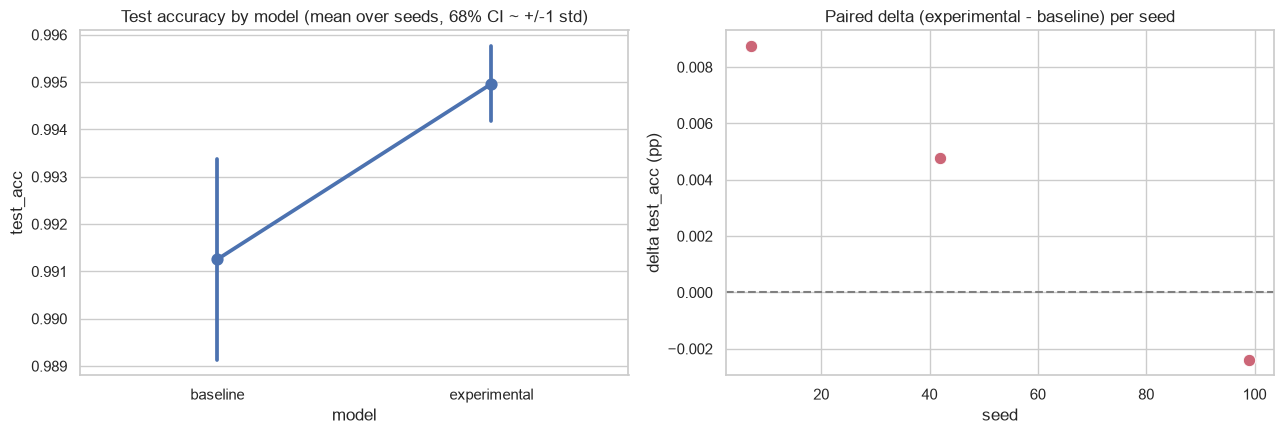

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.pointplot(data=multi_df, x='model', y='test_acc',
              errorbar=('ci', 68), markers='o', linestyles='-', ax=axes[0])
axes[0].set_title('Test accuracy by model (mean over seeds, 68% CI ~ +/-1 std)')
axes[0].set_ylabel('test_acc')

# Paired delta dot plot — one dot per seed.
sns.scatterplot(data=piv.reset_index(), x='seed', y='delta_exp_minus_base',
                 s=80, ax=axes[1], color='#CC6677')
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('Paired delta (experimental - baseline) per seed')
axes[1].set_ylabel('delta test_acc (pp)')
axes[1].set_xlabel('seed')
plt.tight_layout(); plt.show()